In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df1 = pd.read_csv('AirPassengers.csv')

In [3]:
df1.dtypes

Month          object
#Passengers     int64
dtype: object

In [7]:
df1.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [9]:
#we are providing inputs to tell pandas that we are trying to work with time series
df1 = pd.read_csv('AirPassengers.csv',parse_dates = ['Month'])

In [11]:
df1.dtypes

Month          datetime64[ns]
#Passengers             int64
dtype: object

In [13]:
df1.head()

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [15]:
#It is recommended that we make our time series reference as the index
df1 = pd.read_csv('AirPassengers.csv',parse_dates = ['Month'], index_col = 'Month')

In [17]:
df1.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [20]:
df1.columns = ['Pax']

In [22]:
df1.head()

,Pax
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [24]:
df1['1951-04-01':'1952-03-01'] #data slicing using our new index

,Pax
Month,
1951-04-01,163
1951-05-01,172
1951-06-01,178
1951-07-01,199
1951-08-01,199
1951-09-01,184
1951-10-01,162
1951-11-01,146
1951-12-01,166


In [30]:
#to extract values corresponding to a specific time point
df1.loc['1960-05-01'] 

Pax    472
Name: 1960-05-01 00:00:00, dtype: int64

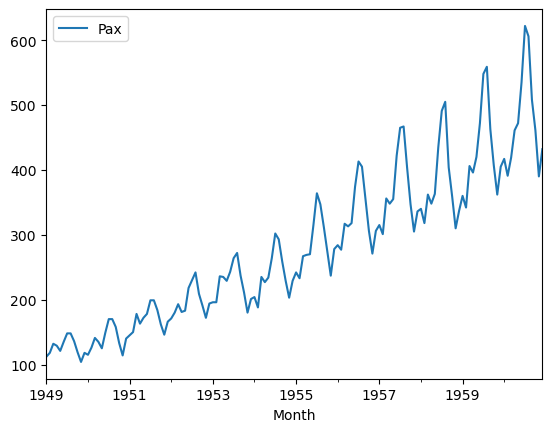

In [32]:
#Plot the time series

df1.plot()
plt.show()

In [34]:
#trend = upward
#seasonality = not constant
#So, we will need a multiplicative model

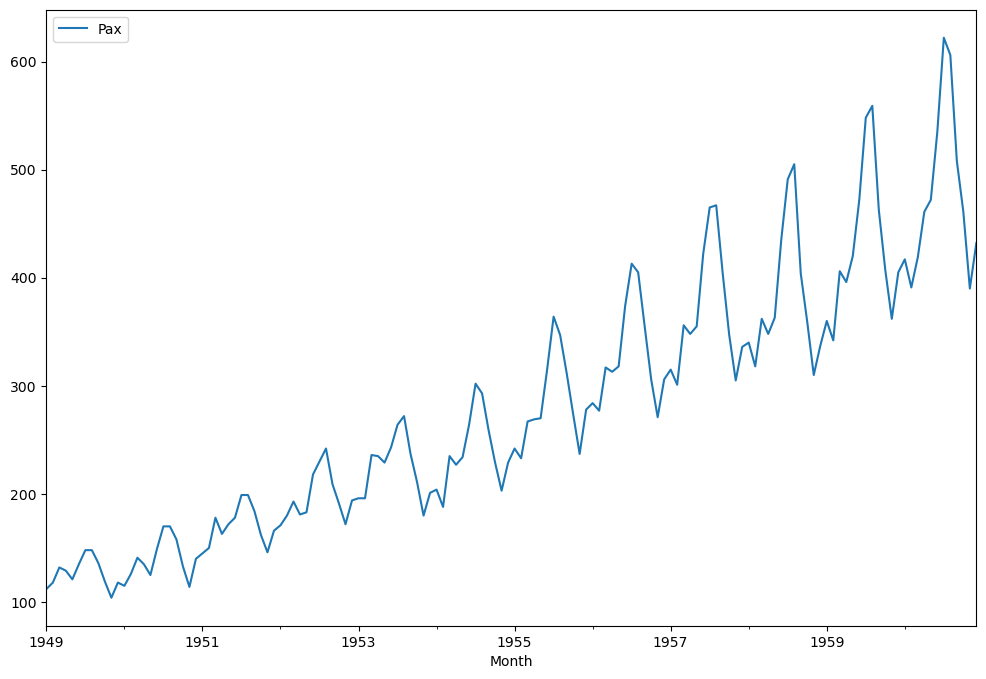

In [36]:
#Increase the figure size
from pylab import rcParams
rcParams['figure.figsize'] = 12,8
df1.plot()
plt.show()

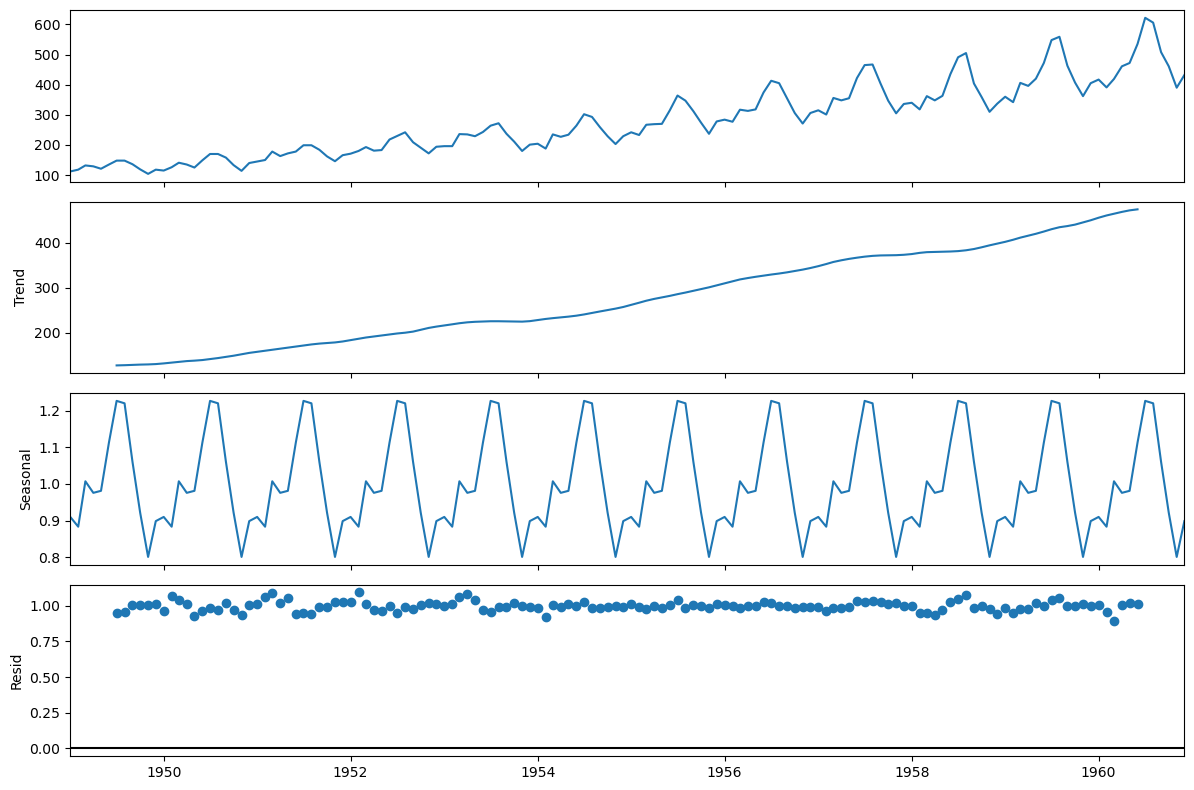

In [38]:
#Decompose the time series multiplicatively

df1_mul_decompose = seasonal_decompose(df1, model = 'multiplicative')
df1_mul_decompose.plot()
plt.show()

In [40]:
#to convert a multiplicative model to additive model we have to take a log
# y = T*S*I
#log y = log T + log S + log I

In [42]:
#now seasonality will be constant

In [44]:
df1_log = df1.copy()

In [46]:
df1_log['Pax'] = np.log(df1)

In [48]:
df1_log.Pax

Month
1949-01-01    4.718499
1949-02-01    4.770685
1949-03-01    4.882802
1949-04-01    4.859812
1949-05-01    4.795791
                ...   
1960-08-01    6.406880
1960-09-01    6.230481
1960-10-01    6.133398
1960-11-01    5.966147
1960-12-01    6.068426
Name: Pax, Length: 144, dtype: float64

In [50]:
#Visualizing the log transformed seires

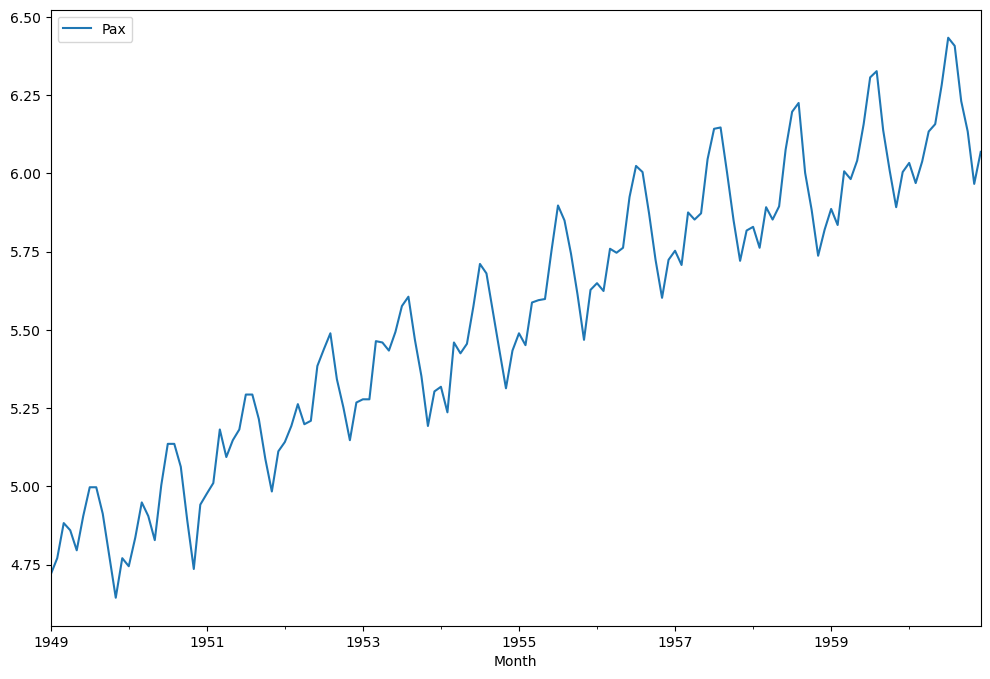

In [52]:
df1_log.plot()
plt.show()

In [54]:
#less variation in seasonal pattern

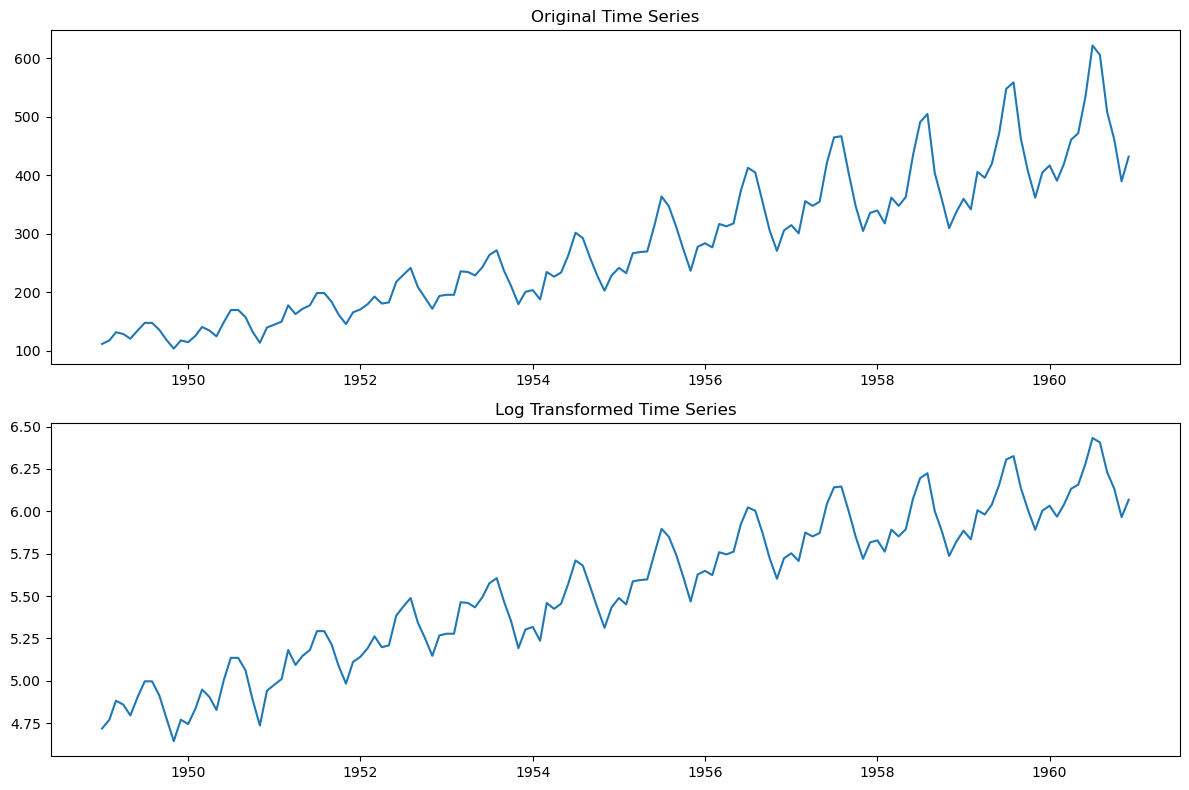

In [58]:
 #Compare with original series
plt.subplot(2,1,1)
plt.title('Original Time Series')
plt.plot(df1)

plt.subplot(2,1,2)
plt.title('Log Transformed Time Series')
plt.plot(df1_log)
plt.tight_layout()

In [60]:
# hence no more upward trend in case of seasonality